In [ ]:
"""
Customer Churn Prediction with KNN
Author: Carlos Felipe Valencia
Description: Predict whether a telecom customer will churn or not using KNN
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# Load the customer churn dataset
print("Loading customer churn dataset...")
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# The dataset is a CSV file with customer information and a churn target column
print(f"\nDataset type: {type(df)}")
print(f"Number of samples: {len(df)}")
print(f"Number of features: {len(df.columns) - 1}")
print(f"Target classes: {df['Churn'].unique()}")

print("\nFirst few rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nTarget distribution:")
print(df["Churn"].value_counts())
print(f"Churn Yes: {(df['Churn'] == 'Yes').sum()}")
print(f"Churn No: {(df['Churn'] == 'No').sum()}")

Loading customer churn dataset...

Dataset type: <class 'pandas.core.frame.DataFrame'>
Number of samples: 7043
Number of features: 20
Target classes: ['No' 'Yes']

First few rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL


BASIC STATISTICS
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000

MISSING VALUES
✓ No missing values found!

FEATURE DISTRIBUTIONS
Saved visualization to 'churn_feature_distributions.png'


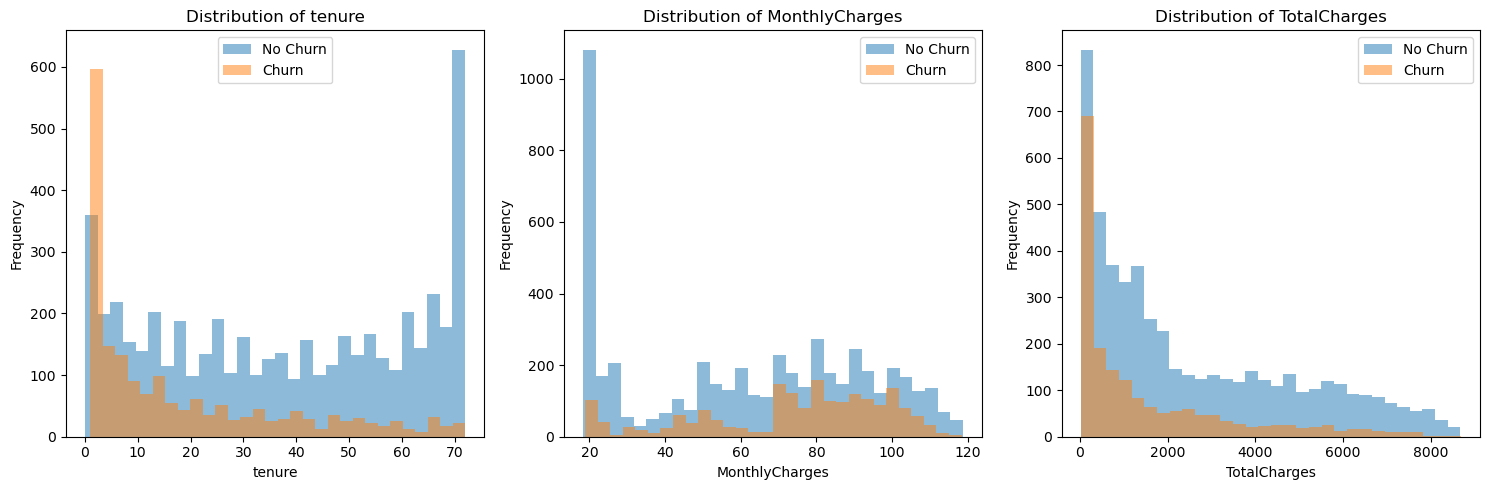

In [3]:
# Basic statistics
print("\n" + "="*50)
print("BASIC STATISTICS")
print("="*50)
print(df.describe())

# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found!")
else:
    print(missing[missing > 0])

# Visualize feature distributions (select a few key features)
print("\n" + "="*50)
print("FEATURE DISTRIBUTIONS")
print("="*50)

# Select a few representative  NUMERICS IN churn
key_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# IMPORTANT: convert TotalCharges into numbers
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    axes[idx].hist(df[df['Churn'] == 'No'][feature].dropna(), alpha=0.5, label='No Churn', bins=30)
    axes[idx].hist(df[df['Churn'] == 'Yes'][feature].dropna(), alpha=0.5, label='Churn', bins=30)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('churn_feature_distributions.png', dpi=150, bbox_inches='tight')
print("Saved visualization to 'churn_feature_distributions.png'")
plt.show()

## Observations

The feature distributions show clear differences between churned and non-churned customers. 

Customers with lower tenure tend to churn more frequently, indicating that newer customers are more likely to leave the service. Additionally, customers with higher monthly charges appear to have a higher probability of churning.

These patterns suggest that both customer lifetime and pricing play an important role in churn behavior.

In [4]:
# Create a copy of the dataframe for preprocessing
df_processed = df.copy()

print("\n" + "="*50)
print("DATA PREPROCESSING")
print("="*50)

# Convert TotalCharges to numeric
df_processed["TotalCharges"] = pd.to_numeric(df_processed["TotalCharges"], errors="coerce")

# Handle missing values in TotalCharges
missing_total_charges = df_processed["TotalCharges"].isnull().sum()
print(f"Missing values in TotalCharges after conversion: {missing_total_charges}")

df_processed["TotalCharges"] = df_processed["TotalCharges"].fillna(df_processed["TotalCharges"].median())

# Drop customerID because it is an identifier, not a predictive feature
df_processed = df_processed.drop("customerID", axis=1)

# Convert target variable to binary
df_processed["Churn"] = df_processed["Churn"].map({"No": 0, "Yes": 1})

# Convert categorical variables to numeric using one-hot encoding
df_encoded = pd.get_dummies(df_processed, drop_first=True)

print("\nPreprocessing complete!")
print(f"Original shape: {df.shape}")
print(f"Processed shape: {df_encoded.shape}")

print("\nFirst few rows of processed dataset:")
print(df_encoded.head())

print("\nTarget distribution after encoding:")
print(df_encoded["Churn"].value_counts())


DATA PREPROCESSING
Missing values in TotalCharges after conversion: 11

Preprocessing complete!
Original shape: (7043, 21)
Processed shape: (7043, 31)

First few rows of processed dataset:
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone se

In [5]:
# Separate features and target
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print("\n" + "="*50)
print("FEATURES AND TARGET")
print("="*50)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print("\nTarget distribution:")
print(y.value_counts())
print(f"No Churn (0): {(y == 0).sum()}")
print(f"Churn (1): {(y == 1).sum()}")


FEATURES AND TARGET
Features shape: (7043, 30)
Target shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
No Churn (0): 5174
Churn (1): 1869


In [6]:
# Split into training and testing sets
# random_state ensures reproducibility
# stratify=y ensures both sets have similar class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n" + "="*50)
print("DATA SPLIT")
print("="*50)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training features: {X_train.shape[1]}")
print(f"Test features: {X_test.shape[1]}")

# Verify class distribution in both sets
print("\nTraining set target distribution:")
print(y_train.value_counts())
print(f"  No Churn (0): {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Churn (1): {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")

print("\nTest set target distribution:")
print(y_test.value_counts())
print(f"  No Churn (0): {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Churn (1): {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")


DATA SPLIT
Training set size: 5634 samples
Test set size: 1409 samples
Training features: 30
Test features: 30

Training set target distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64
  No Churn (0): 4139 (73.5%)
  Churn (1): 1495 (26.5%)

Test set target distribution:
Churn
0    1035
1     374
Name: count, dtype: int64
  No Churn (0): 1035 (73.5%)
  Churn (1): 374 (26.5%)


## Data Preprocessing

The dataset was successfully prepared for modeling. Categorical variables were converted into numerical format using one-hot encoding, and the target variable (Churn) was transformed into binary values (0 = No churn, 1 = Churn).

The dataset contains 7,043 samples and 30 features after encoding. Additionally, the data shows class imbalance, with significantly more non-churn customers than churn customers.

This imbalance suggests that evaluation metrics such as recall will be particularly important when assessing model performance.

In [7]:
# Create KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

print("KNN classifier trained successfully!")
print(f"Number of neighbors (k): {knn.n_neighbors}")

# Make predictions
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

print(f"\nTraining predictions: {len(y_train_pred)}")
print(f"Test predictions: {len(y_test_pred)}")

KNN classifier trained successfully!
Number of neighbors (k): 5

Training predictions: 5634
Test predictions: 1409


## Model Training

A K-Nearest Neighbors (KNN) classifier was trained using the processed dataset. The model uses 5 neighbors to make predictions based on similarity between customers.

Predictions were generated for both training and test datasets to evaluate performance in the next step.